In [ ]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import moments, moments_central
from scipy.ndimage import affine_transform, center_of_mass
from scipy.ndimage import shift as ndimage_shift

from torchvision import datasets

In [ ]:
os.makedirs('../data', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

In [ ]:
TRAIN_PER_CLASS = 5000
TEST_PER_CLASS  = 800

# Download MNIST dataset

In [63]:
# Download train and test MNIST datasets
train_dataset = datasets.MNIST(root="../data", train=True, download=True)
test_dataset = datasets.MNIST(root="../data", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:23<00:00, 423kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 109kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 329kB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [64]:
train_targets = np.array(train_dataset.targets)
test_targets = np.array(test_dataset.targets)

train_counts = np.bincount(train_targets)
test_counts = np.bincount(test_targets)

print("Train set class distribution:")
for digit, count in enumerate(train_counts):
    print(f"Digit {digit}: {count}")

print("\nTest set class distribution:")
for digit, count in enumerate(test_counts):
    print(f"Digit {digit}: {count}")

Train set class distribution:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949

Test set class distribution:
Digit 0: 980
Digit 1: 1135
Digit 2: 1032
Digit 3: 1010
Digit 4: 982
Digit 5: 892
Digit 6: 958
Digit 7: 1028
Digit 8: 974
Digit 9: 1009


C:\Users\stanj\AppData\Local\Temp\ipykernel_20932\1328157199.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_targets = np.array(train_dataset.targets)
C:\Users\stanj\AppData\Local\Temp\ipykernel_20932\1328157199.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_targets = np.array(test_dataset.targets)


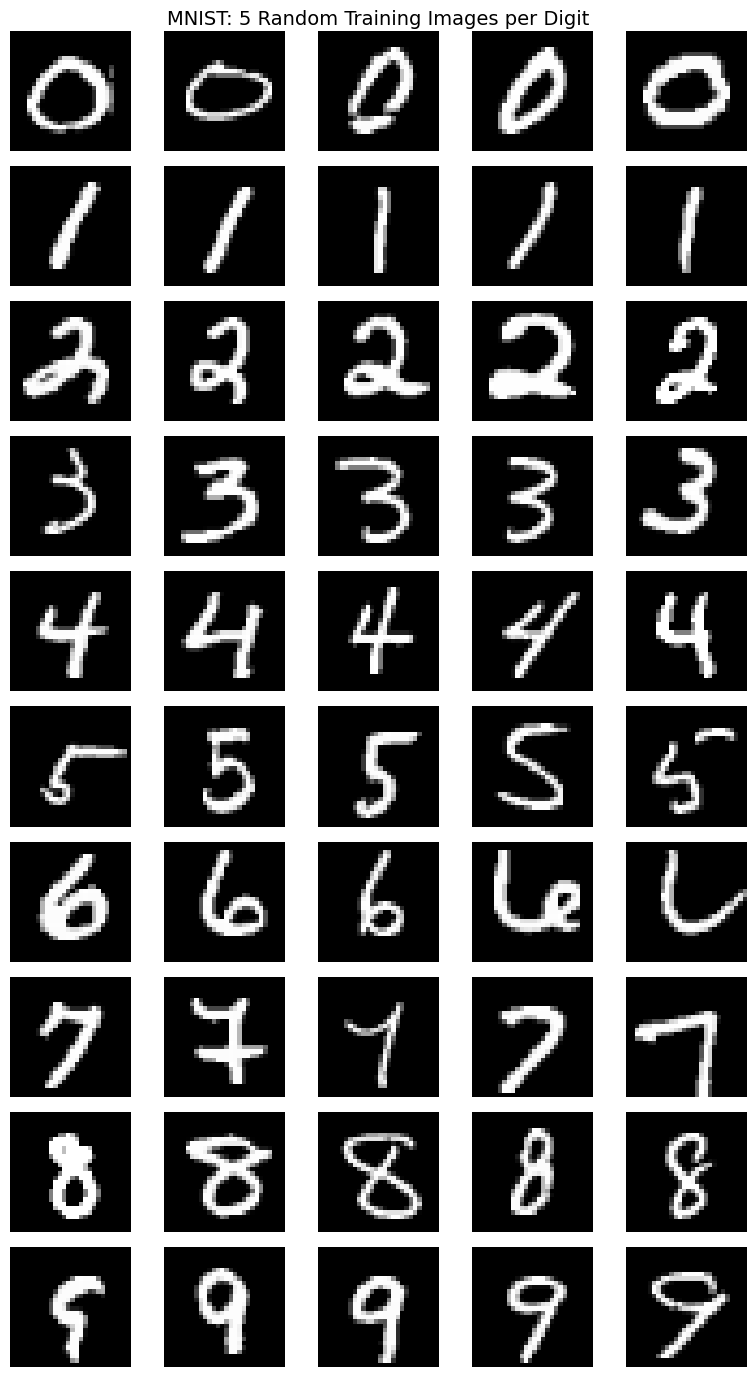

In [65]:
rng = random.Random()
fig, axes = plt.subplots(10, 5, figsize=(8, 14))

for digit in range(10):
    digit_indices = np.where(train_targets == digit)[0]
    sampled_indices = rng.sample(digit_indices.tolist(), 5)

    for col, idx in enumerate(sampled_indices):
        image, label = train_dataset[idx]
        axes[digit, col].imshow(np.array(image), cmap="gray")
        axes[digit, col].axis("off")
        if col == 0:
            axes[digit, col].set_ylabel(f"{digit}", rotation=0, labelpad=15, va="center")

fig.suptitle("MNIST: 5 Random Training Images per Digit", fontsize=14)
plt.tight_layout()
plt.show()

# Affine Alignment
- The deskew and center of mass alignment step seems redundant, only padding to 32x32 is kept.

## Deskew (Remove Slant)

In [66]:

def deskew(image: np.ndarray) -> np.ndarray:
    m = moments(image)
    if abs(m[0, 0]) < 1e-2:
        return image                   

    cy = m[1, 0] / m[0, 0]
    cx = m[0, 1] / m[0, 0]
    mu = moments_central(image, center=(cy, cx))

    if abs(mu[0, 2]) < 1e-2:
        return image                    

    alpha = mu[1, 1] / mu[0, 2]
    M = np.array([[1,      0],
                  [-alpha, 1]], dtype=np.float64)

    h, w   = image.shape
    centre = np.array([h / 2.0, w / 2.0])
    offset = centre - M @ centre       

    return affine_transform(image, M, offset=offset, cval=0.0, order=1)

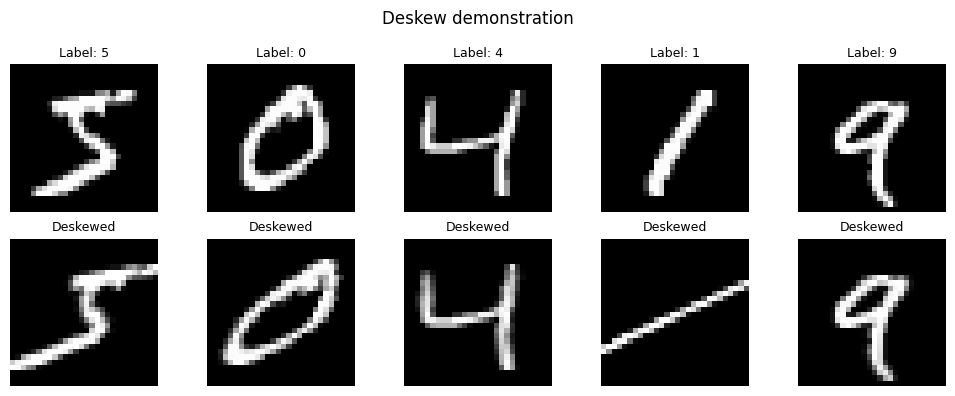

In [67]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    raw = np.array(train_dataset[i][0], dtype=np.float32)
    axes[0, i].imshow(raw,          cmap='gray')
    axes[0, i].set_title(f'Label: {train_dataset[i][1]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(deskew(raw),  cmap='gray')
    axes[1, i].set_title('Deskewed', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Deskew demonstration', fontsize=12)
plt.tight_layout()
plt.show()

## Centre of Mass Centering

In [68]:
def center_digit(image: np.ndarray, target: tuple = (14, 14)) -> np.ndarray:
    cy, cx = center_of_mass(image)
    if np.isnan(cy) or np.isnan(cx):
        return image               
    dy = target[0] - cy
    dx = target[1] - cx
    return ndimage_shift(image, shift=[dy, dx], cval=0.0, order=1)

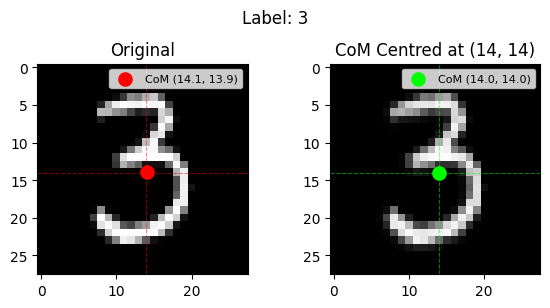

In [69]:
_demo_idx = 50
_raw = np.array(train_dataset[_demo_idx][0], dtype=np.float32)
cy0, cx0 = center_of_mass(_raw)
_centered = center_digit(_raw, target=(14, 14))
cy1, cx1 = center_of_mass(_centered)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(_raw,      cmap='gray')
axes[0].scatter([cx0], [cy0], color='red',  s=90, zorder=5, label=f'CoM ({cx0:.1f}, {cy0:.1f})')
axes[0].axhline(14, color='red',  lw=0.8, linestyle='--', alpha=0.5)
axes[0].axvline(14, color='red',  lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Original')
axes[0].legend(fontsize=8)
axes[1].imshow(_centered, cmap='gray')
axes[1].scatter([cx1], [cy1], color='lime', s=90, zorder=5, label=f'CoM ({cx1:.1f}, {cy1:.1f})')
axes[1].axhline(14, color='lime', lw=0.8, linestyle='--', alpha=0.5)
axes[1].axvline(14, color='lime', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('CoM Centred at (14, 14)')
axes[1].legend(fontsize=8)
plt.suptitle(f'Label: {train_dataset[_demo_idx][1]}', fontsize=12)
plt.tight_layout()
plt.show()

## Pad to 32 x 32

In [ ]:

def pad_to_32(image: np.ndarray, target: int = 32) -> np.ndarray:
    h, w    = image.shape
    pad_h   = target - h         
    pad_w   = target - w
    top     = pad_h // 2          
    bottom  = pad_h - top         
    left    = pad_w // 2
    right   = pad_w - left
    return np.pad(image, ((top, bottom), (left, right)),
                  mode='constant', constant_values=0.0)


_sample = np.array(train_dataset[0][0], dtype=np.float32)
print(f"Before padding: {_sample.shape} ’  After: {pad_to_32(_sample).shape}")

Before padding: (28, 28)  â†’  After: (32, 32)


## Singular Function for affine alignment

In [71]:
def affine_align(image) -> np.ndarray:
    img = np.array(image, dtype=np.float32)
    # img = deskew(img)
    # img = center_digit(img, target=(14, 14))
    img = pad_to_32(img)
    return img

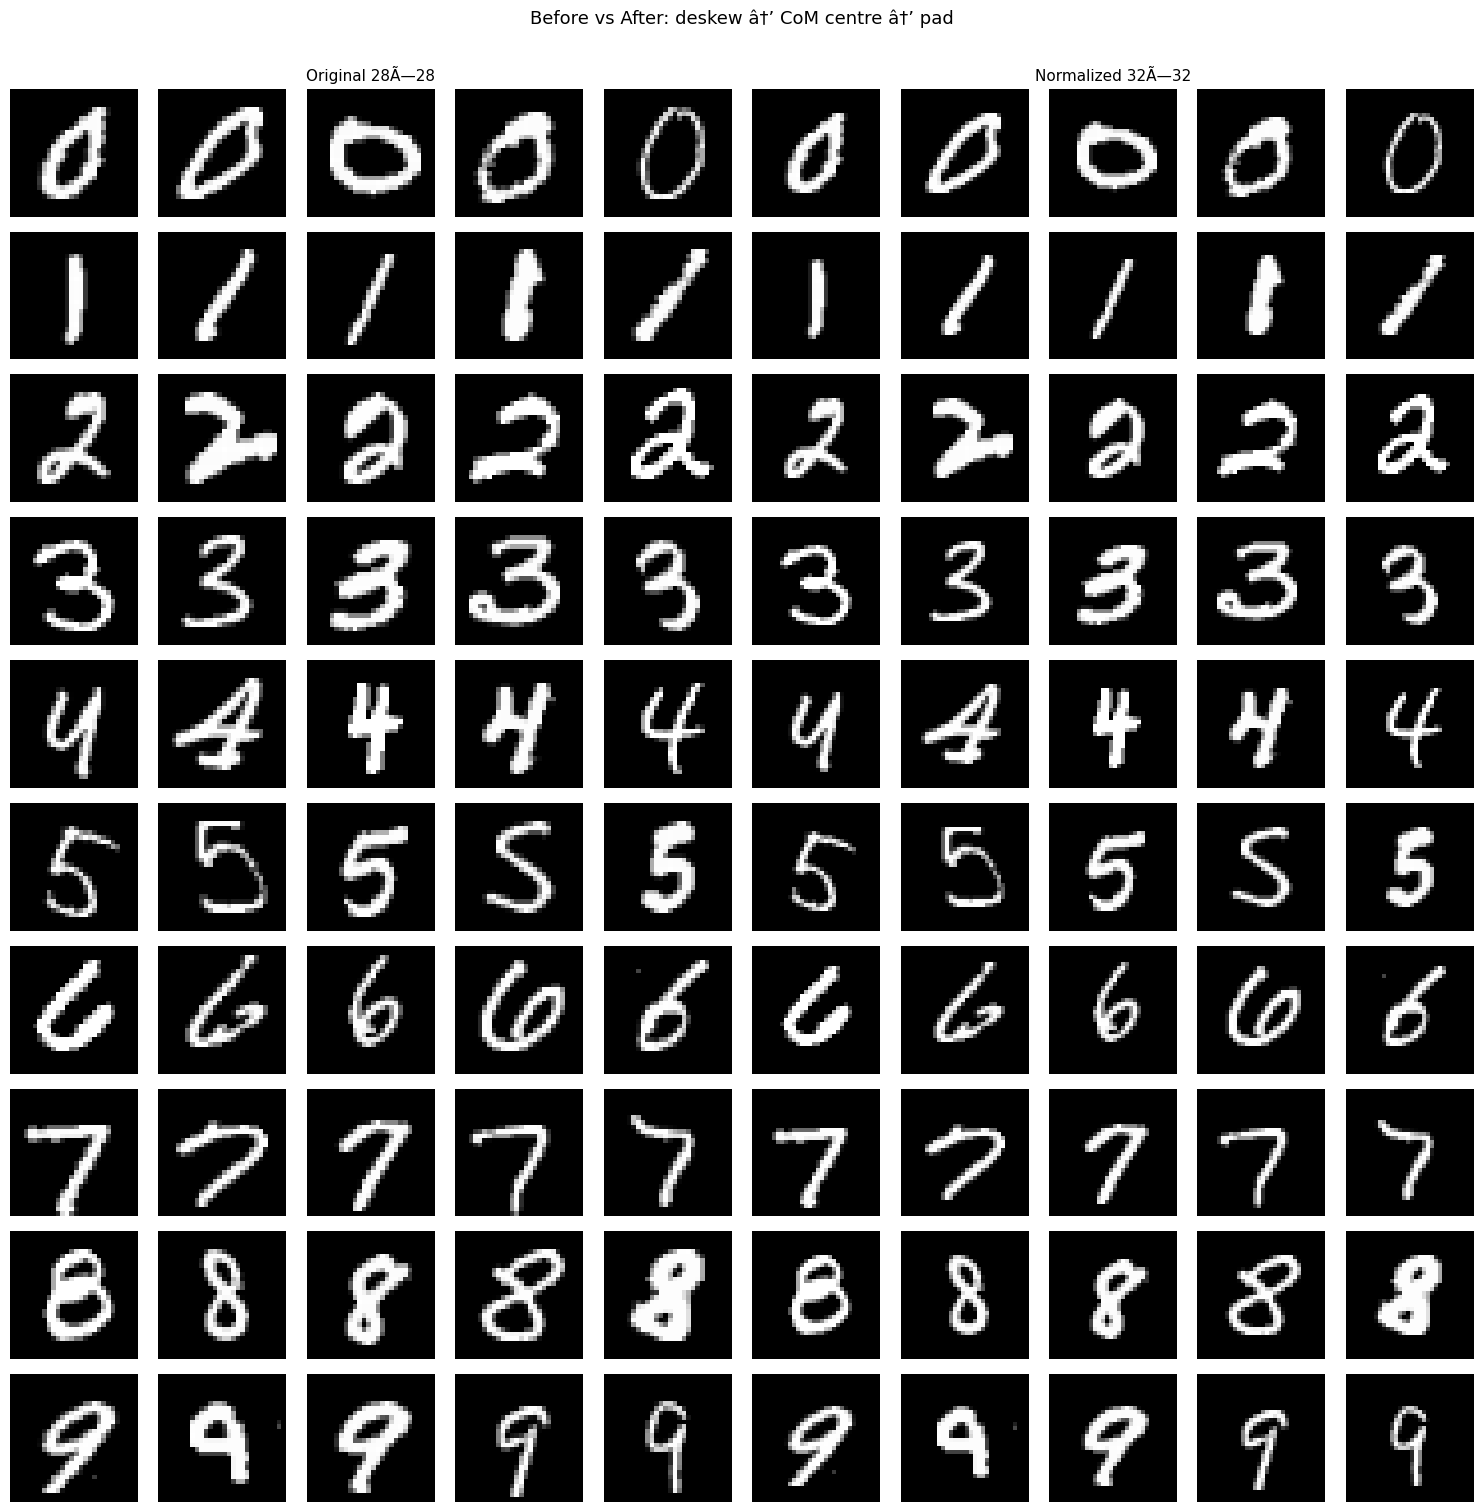

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
rng_vis = random.Random(0)

for digit in range(10):
    digit_indices = np.where(train_targets == digit)[0]
    idxs = rng_vis.sample(digit_indices.tolist(), 5)
    for col, idx in enumerate(idxs):
        raw  = np.array(train_dataset[idx][0], dtype=np.float32)
        norm = affine_align(raw)
        axes[digit, col].imshow(raw,  cmap='gray', vmin=0, vmax=255)
        axes[digit, col].axis('off')
        axes[digit, col + 5].imshow(norm, cmap='gray', vmin=0, vmax=255)
        axes[digit, col + 5].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, labelpad=12, va='center', fontsize=12)

axes[0, 2].set_title('Original 28x28', fontsize=11, pad=6)
axes[0, 7].set_title('Normalized 32x32', fontsize=11, pad=6)
fig.suptitle('Before vs After: deskew → CoM centre → pad', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
def sample_per_class(targets, n_per_class, rng_seed=42):
    rng = random.Random(rng_seed)
    indices = []
    for digit in range(10):
        digit_indices = np.where(targets == digit)[0].tolist()
        indices.extend(rng.sample(digit_indices, n_per_class))
    return indices

def process_selected(dataset, indices):
    images, labels = [], []
    for idx in indices:
        img, label = dataset[idx]
        images.append(affine_align(img))
        labels.append(label)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int64)

train_indices = sample_per_class(train_targets, TRAIN_PER_CLASS)
test_indices  = sample_per_class(test_targets,  TEST_PER_CLASS)

print(f'Processing {TRAIN_PER_CLASS} x 10 = {len(train_indices):,} training images...')
train_images_norm, train_labels_norm = process_selected(train_dataset, train_indices)

print(f'Processing {TEST_PER_CLASS} x 10 = {len(test_indices):,} test images...')
test_images_norm,  test_labels_norm  = process_selected(test_dataset,  test_indices)


train_images_norm /= 255.0
test_images_norm  /= 255.0

pixel_mean = float(train_images_norm.mean())
pixel_std  = float(train_images_norm.std())
train_images_norm = (train_images_norm - pixel_mean) / pixel_std
test_images_norm  = (test_images_norm  - pixel_mean) / pixel_std

print(f'pixel_mean={pixel_mean:.4f}  pixel_std={pixel_std:.4f}')
print(f'Train  mean={train_images_norm.mean():.4f}  std={train_images_norm.std():.4f}')
print(f'Test   mean={test_images_norm.mean():.4f}   std={test_images_norm.std():.4f}')

save_path = '../data/mnist_normalized_32x32.npz'
np.savez_compressed(
    save_path,
    train_images=train_images_norm,
    train_labels=train_labels_norm,
    test_images=test_images_norm,
    test_labels=test_labels_norm,
    pixel_mean=np.array(pixel_mean),
    pixel_std=np.array(pixel_std),
)

print(f'Saved -> {save_path}')
print(f'train_images : {train_images_norm.shape}  dtype={train_images_norm.dtype}')
print(f'test_images  : {test_images_norm.shape}   dtype={test_images_norm.dtype}')
print(f'Pixel range  : [{train_images_norm.min():.3f}, {train_images_norm.max():.3f}]')


Processing 5000 x 10 = 50,000 training images...
Processing 800 x 10 = 8,000 test images...
pixel_mean=0.1007  pixel_std=0.2760
Train  mean=-0.0000  std=1.0000
Test   mean=0.0051   std=1.0078
Saved -> ./data/mnist_normalized_32x32.npz
train_images : (50000, 32, 32)  dtype=float32
test_images  : (8000, 32, 32)   dtype=float32
Pixel range  : [-0.365, 3.259]
